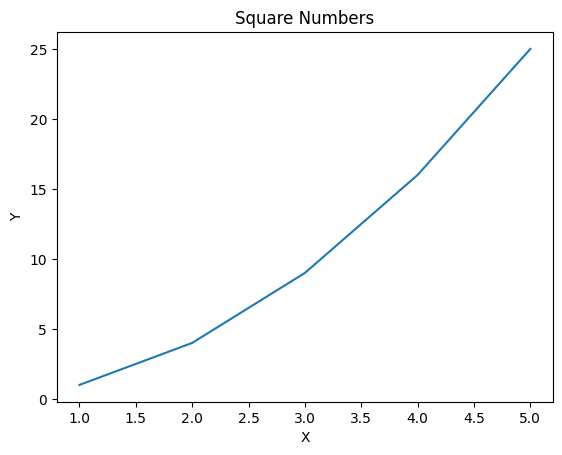

In [ ]:
# Listing 1.1 Imperative library

import matplotlib.pyplot as plt

x = [1, 2, 3, 4, 5]
y = [1, 4, 9, 16, 25]

plt.plot(x, y)
plt.title('Square Numbers')
plt.xlabel('X')
plt.ylabel('Y')

plt.show()

In [ ]:
# install altair
pip install altair vega_datasets

In [ ]:
# Listing 1.2 Imperative library

import altair as alt
import pandas as pd

df = pd.DataFrame({'x': [1, 2, 3, 4, 5], 'y': [1, 4, 9, 16, 25]})

chart = alt.Chart(df).mark_line().encode(
    x='x',
    y='y'
).properties(
    title='Square Numbers'
)

chart


alt.Chart(...)

In [ ]:
# Listing 2.1 Chart in Altair

import altair as alt
import pandas as pd

# Create data for the DataFrame
data = {'Name': ['Alice', 'Bob', 'Charlie'],
        'Age': [25, 30, 35],
        'City': ['New York', 'Paris', 'London']
}

# Create the DataFrame from the data
df = pd.DataFrame(data)

# Print the dataframe
print(df)

# Create the chart
chart = alt.Chart(df)


      Name  Age      City
0    Alice   25  New York
1      Bob   30     Paris
2  Charlie   35    London


In [ ]:
# Listing 2.2 Mark in Altair

chart = alt.Chart(df).mark_bar()

In [ ]:
# Listing 2.3 Encodings in Altair

import pandas as pd
import altair as alt

# Create data for the DataFrame
data = {'Name': ['Alice', 'Bob', 'Charlie'],
        'Age': [25, 30, 35],
        'City': ['New York', 'Paris', 'London']
}


# Create the DataFrame from the data
df = pd.DataFrame(data)

# Create the chart
chart_2_3 = alt.Chart(df).mark_bar(
).encode(
    x = 'Age:Q',
    y = 'Name:N'
)

chart.save('chart_2_3.html')

# to plot the chart inline.
chart_2_3.display()

alt.Chart(...)

In [ ]:
# save to laptop
# - you will be prompted to provide the destination

from google.colab import files
files.download('/content/chart_2_3.html')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Listing 2.4 Loading the dataset as a Pandas DataFrame

# import file from laptop
# from google.colab import files
# uploaded = files.upload()
#
# The aboved failed. uploaded file manually using "upload" command from "content"
#   folder context menu

import pandas as pd

df = pd.read_csv('/content/tourist_arrivals_countries.csv', parse_dates=['Date'])


In [ ]:
# Listing 2.5 Building a summary report

In [ ]:
# install missing module ydata_profiling
!pip install ydata_profiling

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 357.3/357.3 kB 7.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.7/102.7 kB 11.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.5/679.5 kB 31.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.5/296.5 kB 33.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 101.7 MB/s eta 0:00:00
  Created wheel for htmlmin: filename=htmlmin-0.1.12-py3-none-any.whl size=27081 sha256=f19f3e0dca4b16e5d6ec3d7ee210b9816b1cbe0297249bd413dd919f6b57e8af
  Stored in directory: /root/.cache/pip/wheels/dd/91/29/a79cecb328d01739e64017b6fb9a1ab9d8cb1853098ec5966d
Successfully built htmlmin


In [ ]:
from ydata_profiling import ProfileReport

eda = ProfileReport(df)
eda.to_file(output_file='eda.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
# Listing 2.6 Building the raw chart in Altair

import altair as alt

df2 = pd.melt(df,
              id_vars='Date',
              value_name='Tourist Arrivals',
              var_name='Country')

chart_2_6 = alt.Chart(df2).mark_line().encode(
    x = 'Date:T',
    y = 'Tourist Arrivals:Q',
    color=alt.Color('Country:N')
)

chart_2_6.save('chart_2_6.html')

In [ ]:
# Listing 2.7 Removing missing values from the dataset

mask_fr = df['FR'].isnull() == False
mask_uk = df['UK'].isnull() == False
mask_es = df['ES'].isnull() == False
df = df[(mask_fr) & (mask_uk) & (mask_es)]

In [ ]:
# Listing 2.8 Grouping by year and calculating the average value

# group data by year and calculate the average value
# select only data for 1994 (the first in the dataset) and 2018 (the penultimate in the dataset).

df2 = df.copy()
df2.loc[:, 'Year'] = df['Date'].dt.year

# What is this line doing: df2.loc[:, 'Year'] = df['Date'].dt.year

# This line of code is performing two main operations:

# df['Date'].dt.year:
# It extracts the year from the Date column of the DataFrame df. The .dt
#   accessor is used to extract date-related attributes from a pandas Series or
#   DataFrame column of type datetime64[ns]. Here, .year retrieves the year from
#    the date.

# df2.loc[:, 'Year'] = ...:
# This part is assigning the extracted year values to a new column named 'Year'
#   in the DataFrame df2.

# So, in summary, the code is creating (or updating) a column named 'Year' in
#   the DataFrame df2, where each entry in this column corresponds to the year
#   extracted from the Date column of the df DataFrame.


df2 = df2.groupby(by='Year').mean(numeric_only=True)
df2 = df2.iloc[[0, -2]]
df2.reset_index(inplace=True)

# df2 = df2.groupby(by='Year').mean(numeric_only=True)
#  This line groups the df2 DataFrame by unique values in the 'Year' column.
#  After grouping, it calculates the mean of all numeric columns for each unique
#    'Year'.
#  The result is a new DataFrame where each row represents a unique 'Year', and
#    the columns contain the average values for that year.
#  numeric_only=True ensures that the mean is calculated only for numeric
#   columns.

# df2 = df2.iloc[[0, -2]]
#  This line selects the first row and the second-to-last row of the df2
#   DataFrame.
#  iloc is used for integer-location based indexing, and the indices [0, -2]
#   represent the first and second-to-last rows respectively.
#  The resulting DataFrame df2 will now only have two rows: the first and the
#   second-to-last rows from the original df2 (which was the grouped and
#   averaged DataFrame).

# df2.reset_index(inplace=True)
#  After grouping by 'Year', the 'Year' values become the index of the DataFrame.
#  This line resets the index of df2 to the default integer index.
#  The original 'Year' index will become a column in the DataFrame.
#  inplace=True means the operation is done in-place, and the DataFrame is
#    modified directly without the need to reassign it.

# In summary, the code is grouping the DataFrame df2 by 'Year', calculating the
#   mean of numeric columns for each year, then selecting only the first and
#   second-to-last rows, and finally resetting the DataFrame's index so that
#   'Year' becomes a regular column again.

In [ ]:
# Listing 2.9 Building the chart in Altair

df3 = pd.melt(df2, id_vars='Year',value_name='Tourist Arrivals', var_name='Country')

chart = alt.Chart(df3).mark_line(point=alt.OverlayMarkDef()).encode(
    x = alt.X('Year:O',
    title='',
    axis=alt.Axis(labelAngle=0)),
    y = 'Tourist Arrivals:Q',
    color=alt.Color('Country:N')
).properties(
    width=400,
    height=300,
    title='Countries Trend in Arrivals'
)


# chart.save(‘chart.html’)
chart.save('chart_2_9.html')

In [ ]:
# Listing 2.10 Preparing the DataFrame

mask = df3['Country'] == 'PT'
df4 = df3.loc[~mask].groupby('Year').mean().reset_index()
df4['Country'] = 'Others (mean)'
df5 = df3.loc[mask].append(df4, ignore_index=True)

<ipython-input-24-bcfb1164f286>:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df4 = df3.loc[~mask].groupby('Year').mean().reset_index()
<ipython-input-24-bcfb1164f286>:6: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df5 = df3.loc[mask].append(df4, ignore_index=True)


In [ ]:
# display results to compare to Table 2.2
df5

,Year,Country,Tourist Arrivals
0,1994,PT,5.633548e+05
1,2018,PT,1.703339e+06
2,1994,Others (mean),4.503851e+06
3,2018,Others (mean),9.082776e+06


In [ ]:
# Listing 2.11 Drawing the chart with Portugal and Average

chart_2_11 = alt.Chart(df5).mark_line(point=alt.OverlayMarkDef()).encode(
    x = alt.X('Year:O', title='', axis=alt.Axis(labelAngle=0)),
    y = 'Tourist Arrivals:Q',
    color=alt.Color('Country:N')
).properties(
    width=400,
    height=300,
    title='Countries Trend in Arrivals'
)
chart.save('chart_2_11.html')

In [ ]:
# Listing 2.12 Calculating the percentage increase for each country

mask_first = df5['Year'] == 1994
mask_last = df5['Year'] == 2018
mask_pt = df5['Country'] == 'PT'
mask_ot = df5['Country'] == 'Others (mean)'

pi_pt = (df5[mask_last & mask_pt]['Tourist Arrivals'].values[0] - \
        df5[mask_first & mask_pt]['Tourist Arrivals'].values[0]) / \
        df5[mask_first & mask_pt]['Tourist Arrivals'].values[0]*100

pi_ot = (df5[mask_last & mask_ot]['Tourist Arrivals'].values[0] - \
        df5[mask_first & mask_ot]['Tourist Arrivals'].values[0]) / \
        df5[mask_first & mask_ot]['Tourist Arrivals'].values[0]*100

In [ ]:
# Listing 2.13 Drawing the chart of percentage increases

df_pi = pd.DataFrame({
    'Date'    : [1994,2018,1994,2018],
    'Country' : ['PT', 'PT', 'Others (mean)', 'Others (mean)'],
    'Tourist Arrivals' : [0, pi_pt, 0, pi_ot]
})


chart_2_13 = alt.Chart(df_pi).mark_line(point=alt.OverlayMarkDef()).encode(
    x = alt.X('Date:O', title='', axis=alt.Axis(labelAngle=0)),
    y = alt.Y('Tourist Arrivals:Q',title='%'),
    color=alt.Color('Country:N')
).properties(
    width=400,
    height=300,
    title='Percentage increase in Tourist Arrivals'
)

chart_2_13.save('chart_2_13.html')

In [ ]:
# Listing 2.14 Adding an annotation to the chart

df_ann = pd.DataFrame({
    'Text' : ['Portugal: ' +
              '{:.2f}'.format(pi_pt) +
              '%',
              'Others (mean): ' +
              '{:.2f}'.format(pi_ot) + '%'],
    'Y' : [pi_pt,pi_ot],
    'X' : [2018,2018],
    'Country' : ['PT', 'Others (mean)']
})

pi = alt.Chart(df_ann).mark_text(
    dx=10,
    align='left',
    fontSize=20
).encode(
    text='Text:N',
    y='Y:Q',
    x='X:O',
    color=alt.Color('Country:N',
                    scale=alt.Scale(domain=['Others (mean)', 'PT'],
                    range=['lightgrey', '#81c01e']),
                    legend=None)
)
total = (chart_2_13 + pi).configure_view(strokeWidth=0)
total.save('chart_2_14.html')

In [ ]:
# Listing 2.15 Adding the context to the chart

annotation = f"""Thanks to the introduction of low-cost flights, Portugal has experienced an increase in tourist arrivals of over 200% in 25 years, even surpassing the increase in the other countries."""
df_text = pd.DataFrame([{'text' : annotation}])

text = alt.Chart(df_text
).mark_text(
    lineBreak='\n',
    align='left',
    fontSize=20,
    y=100,
    color='orange'
).encode(
    text='text:N'
)

# build the final chart
total = (text | chart_2_13 + pi).configure_view(strokeWidth=0)
total.save('chart_2_15.html')

In [ ]:
# Listing 2.16 Adding the call to action to the chart

df_airports = pd.read_csv('/content/airports_cleaned.csv')

df_airports = df_airports.melt(id_vars='Country Name', var_name='Year', value_name='Value')
df_airports.dropna(inplace=True)
df_airports = df_airports[df_airports['Country Name'] == 'Portugal']

airports = alt.Chart(df_airports).mark_line(
    color='#81c01e',
    strokeWidth=6
).encode(
    x=alt.X('Year', axis=alt.Axis(labels=False, ticks=False, grid=False), title=''),
    y=alt.Y('Value', axis=alt.Axis(labels=False, ticks=False, grid=False), title='')
).properties(
    title='Air passengers in Portugal',
    width=150,
    height=100
)

total = (
    (airports & text) | chart_2_13 + pi
).configure_view(
    strokeWidth=0
)

# save chart
total.save('chart_2_16.html')

In [ ]:
# Listing 2.17 Adding the call to action to the chart

chart = alt.Chart(df_pi).mark_line(point=alt.OverlayMarkDef()).encode(
    x = alt.X('Date:O', title='', axis=alt.Axis(labelAngle=0)),
    y = alt.Y('Tourist Arrivals:Q',title='Percentage increase'),
    color=alt.Color('Country:N')
).properties(
    width=400,
    height=300,
    title='Yes, you can build a new swimming pool!'
)

total = (chart + pi | text
).configure_view(
    strokeWidth=0
).configure_title(
    fontSize=20,
    offset=25
)
total.save('chart_2_17.html')

In [ ]:
!pip install config

In [ ]:
# matplotlib version

import pandas as pd
from config import *

df = pd.read_csv('/content/tourist_arrivals_countries.csv', parse_dates=['Date'])
df.head()

,Date,IT,FR,DE,PT,ES,UK
0,1990-01-01,2543920.0,NaN,3185877.0,325138.0,1723786.0,1776000.0
1,1990-02-01,2871632.0,NaN,3588879.0,381539.0,1885718.0,2250000.0
2,1990-03-01,3774702.0,NaN,4272437.0,493957.0,2337847.0,2662000.0
3,1990-04-01,5107712.0,NaN,4689424.0,635822.0,3172302.0,2645000.0
4,1990-05-01,4738376.0,NaN,6045278.0,609952.0,3072480.0,3096000.0


In [ ]:
# Prepare the dataset (See Altair Example)

df2 = pd.melt(df, id_vars='Date', value_name='Tourist Arrivals', var_name='Country')
mask_fr = df['FR'].isnull() == False
mask_uk = df['UK'].isnull() == False
mask_es = df['ES'].isnull() == False
df = df[(mask_fr) & (mask_uk) & (mask_es)]
df2 = df.copy()
df2.loc[:, 'Year'] = df['Date'].dt.year
df2 = df2.groupby(by='Year').mean(numeric_only=True)
df2 = df2.iloc[[0, -2]]
df2.reset_index(inplace=True)
df3 = pd.melt(df2, id_vars='Year',value_name='Tourist Arrivals', var_name='Country')
mask = df3['Country'] == 'PT'
df4 = df3.loc[~mask].groupby('Year').mean().reset_index()
df4['Country'] = 'Others (mean)'
df5 = df3.loc[mask].append(df4, ignore_index=True)
mask_first = df5['Year'] == 1994
mask_last = df5['Year'] == 2018
mask_pt = df5['Country'] == 'PT'
mask_ot = df5['Country'] == 'Others (mean)'

pi_pt = (df5[mask_last & mask_pt]['Tourist Arrivals'].values[0] - \
        df5[mask_first & mask_pt]['Tourist Arrivals'].values[0]) / \
        df5[mask_first & mask_pt]['Tourist Arrivals'].values[0]*100

pi_ot = (df5[mask_last & mask_ot]['Tourist Arrivals'].values[0] - \
        df5[mask_first & mask_ot]['Tourist Arrivals'].values[0]) / \
        df5[mask_first & mask_ot]['Tourist Arrivals'].values[0]*100

df_pi = pd.DataFrame({
    'Date'    : [1994,2018,1994,2018],
    'Country' : ['PT', 'PT', 'Others (mean)', 'Others (mean)'],
    'Tourist Arrivals' : [0, pi_pt, 0, pi_ot]
})

<ipython-input-57-2c75f51ebd54>:15: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df4 = df3.loc[~mask].groupby('Year').mean().reset_index()
<ipython-input-57-2c75f51ebd54>:17: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df5 = df3.loc[mask].append(df4, ignore_index=True)


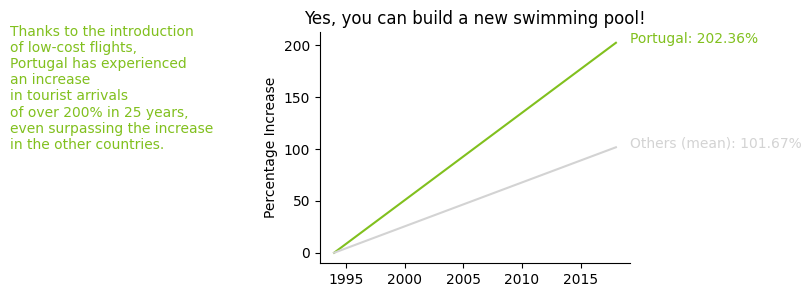

In [ ]:
# draw the chart

from matplotlib.transforms import blended_transform_factory
import matplotlib.pyplot as plt

f, ax = plt.subplots(figsize=(4,3),dpi=100)

for country in df_pi['Country'].unique():
    data = df_pi[df_pi['Country'] == country]
    ax.plot(data['Date'],
            data['Tourist Arrivals'],
            label=country,
            color='#81c01e' if country == 'PT' else 'lightgrey')

trans = blended_transform_factory(x_transform=ax.transAxes, y_transform=ax.transData)
ax.annotate('Others (mean): ' + '{:.2f}'.format(pi_ot) + '%',
            xy=[1,pi_ot],xycoords=trans,
            ha='left',
            color='lightgrey')

ax.annotate('Portugal: ' + '{:.2f}'.format(pi_pt) + '%',
            xy=[1,pi_pt],
            xycoords=trans,
            ha='left',
            color='#81c01e')

annotation = f"""Thanks to the introduction
of low-cost flights,
Portugal has experienced
an increase
in tourist arrivals
of over 200% in 25 years,
even surpassing the increase
in the other countries."""

ax.annotate(annotation,
           xy=[-1,100],
           xycoords=trans,
           ha='left',
           color='#81c01e')

plt.title('Yes, you can build a new swimming pool!')
plt.ylabel('Percentage Increase')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.savefig("chart.png",bbox_inches='tight')
#plt.show()

In [4]:
# Listing 3.14 Building two charts in Altair

import pandas as pd
import altair as alt

df = pd.DataFrame(
    {"Country": ["Japan", "USA", "Germany", "Spain", "France", "Italy"],
     "Medals": [4, 6, 10, 3, 7, 8],
     "Region":["Asia","Americas","Europe","Europe","Europe","Europe"]})


chart1 = alt.Chart(df).mark_bar(color='#636466').encode(
    x='Country',
    y='Medals'
).properties(width=100, title='A bar chart')

chart2 = alt.Chart(df).mark_line(color='#80C11E').encode(
    x='Country',
    y='Medals'
).properties(width=100, title='A line chart')



In [6]:
pip install altair_viewer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 844.5/844.5 kB 6.6 MB/s eta 0:00:00


In [10]:
# Listing 3.15 Building a repeated chart in Altair
import altair_viewer
import pandas as pd
import altair as alt

df = pd.DataFrame({
'X' : [1,2,3,4],
'Y' : [2,4,5,6],
'Z' : [3,4,5,6],
'H' : [5,6,8,9],
'M' : [3,4,5,3],
'Country' : ['USA', 'EU', 'EU', 'USA']
})

fields = df.columns.tolist()
fields.remove('Country')

chart = alt.Chart(df).mark_circle(color='#80C11E').encode(
    alt.X(alt.repeat("column"), type='quantitative'),
    alt.Y(alt.repeat("row"), type='quantitative')
).properties(
    width=100,
    height=100
).repeat(
    row=fields,
    column=fields
)

chart.show()

Displaying chart at http://localhost:40453/


KeyboardInterrupt: ignored

In [9]:
# Listing 3.16 Building an interactive chart in Altair

import pandas as pd
import altair as alt

df = pd.DataFrame(
    {"Country": ["Japan", "USA", "Germany", "Spain", "France", "Italy"],
     "Medals": [4, 6, 10, 3, 7, 8],
     "Region":["Asia","Americas","Europe","Europe","Europe","Europe"]})

chart = alt.Chart(df).mark_bar(color='#636466').encode(
    x='Country',
    y='Medals',
    tooltip=['Country', 'Medals', 'Region']
).properties(
    width=width,
    title='A bar chart'
).interactive()

chart.show()

NameError: ignored

In [11]:
# Listing 3.17 Defining the basic chart

import pandas as pd
import altair as alt

df = pd.DataFrame(
    {"Country": ["Japan", "USA", "Germany", "Spain", "France", "Italy"],
     "Medals": [4, 6, 10, 3, 7, 8],
     "Region":["Asia","Americas","Europe","Europe","Europe","Europe"]})


chart = alt.Chart(df).mark_bar(color='#636466').encode(
    x='Country',
    y='Medals'
).properties(width=width, title='A bar chart')

chart.show()

NameError: ignored

In [12]:
# Listing 3.21 Drawing the raw chart

import pandas as pd
import altair as alt
alt.data_transformers.disable_max_rows()

df = pd.read_csv('/content/population.csv')


df = df.melt(id_vars='Country Name',
             var_name='Year',
             value_name='Population')
df['Year'] = df['Year'].astype('int')

chart = alt.Chart(df).mark_line().encode(
    x = 'Year:Q',
    y = 'Population:Q',
    color = 'Country Name:N'
)

chart.show()

Displaying chart at http://localhost:40453/


KeyboardInterrupt: ignored

# New Section

# New Section